# Perceval Simulation: State-Dependent Multi-Level CZ Gate

**Reference:** Apurav and J. Singh, *Efficient circuit compression by multi-qudit entangling gates in linear optical quantum computation*, arXiv:2602.08394v1 [quant-ph] (2026).

## Overview

This notebook simulates the **state-dependent** realization of the multi-level controlled-Z (CZ) gate described in the above manuscript, using the [Perceval](https://perceval.quandela.net/) linear optics simulation framework.

The gate being simulated is the unitary $U_{\mathrm{MCZ}}$ defined by (Eq. 2 of the manuscript):

$$U_{\mathrm{MCZ}} = \mathbb{1} - 2 \sum_{m \in \mathcal{C}_1} \sum_{n \in \mathcal{C}_2} |m\rangle\langle m|_1 \otimes |n\rangle\langle n|_2$$

where $\mathcal{C}_1$ and $\mathcal{C}_2$ are the sets of **trigger mode indices** in the first and second qudit respectively. This gate applies a conditional phase flip $|m\rangle_1|n\rangle_2 \to -|m\rangle_1|n\rangle_2$ whenever the joint qudit state has mode $m \in \mathcal{C}_1$ and $n \in \mathcal{C}_2$, and acts as identity otherwise.

### This simulation: 4-dimensional qudits ($d = 4$, $g = 2$ qubits each)

Each input qudit encodes $g = 2$ qubits in $d = 2^g = 4$ spatial modes. The trigger sets $\mathcal{C}_1$ and $\mathcal{C}_2$ can be **any non-empty subsets** of the $d$ mode indices — the gate $U_{\mathrm{MCZ}}$ is correctly realised for any such choice, with the same success probability of $1/8$ independent of the trigger sets selected. The only requirement is $|\mathcal{C}_i| < d$.

The specific trigger sets used in this simulation (set in Section 2 below and freely changeable) are:

- `C1 = [1, 2]`, i.e. $\mathcal{C}_1 = \{1, 2\}$, with $k_1 = |\mathcal{C}_1| = 2$
- `C2 = [0, 3]`, i.e. $\mathcal{C}_2 = \{0, 3\}$, with $k_2 = |\mathcal{C}_2| = 2$

To simulate a different gate, simply change `C1` and `C2` in Section 2 and re-run all cells. The ancilla preparation, SMR phase assignments, $O_i$ unitaries, and verification are all parameterised by `C1` and `C2` and will update automatically.

### Physical implementation pipeline (Fig. 2 of the manuscript)

The state-dependent scheme proceeds in four stages:
1. **Ancilla preparation**: Two ancillary qudits ($k_i + 1$ dimensional each) are prepared in a balanced superposition $|\phi'\rangle_3 = \frac{1}{\sqrt{2}}(|\xi_1\rangle_3 + |k_1\rangle_3)$, $|\phi''\rangle_4 = \frac{1}{\sqrt{2}}(|\xi_2\rangle_4 + |k_2\rangle_4)$, using *a priori* knowledge of the input states (Eqs. 4–5 of the manuscript). To keep the choice of trigger modes flexible, however, we keep $d+1$ path modes for ancilla.
2. **Selective Mode Routers (SMRs)**: Each SMR pairs an input qudit with its ancilla and executes a partial swap operation on trigger modes only, flagging whether the input occupies a trigger mode without collapsing its state (Eq. 6 of the manuscript). Success is heralded by single-photon coincidence at each output port.
3. **Basis rotation** ($O_1$, $O_2$): Unitary transformations map the post-SMR ancilla qudits onto a 2-dimensional subspace, producing the entangled resource state of Eq. 7 of the manuscript.
4. **Bell State Measurement (BSM)**: A Hadamard is applied to ancilla 4, followed by a BSM on the two ancillas. The four BSM outcomes correspond to $U_{\mathrm{MCZ}}|\psi\rangle_{12}$ up to known local unitaries $U_1$, $U_2$ (Eq. 8 and 26 of the manuscript).

The overall success probability is $1/8$: a factor of $1/4$ from the two SMRs (each succeeds with probability $1/2$), and a factor of $1/2$ from the linear-optics BSM which can distinguish only two of the four Bell states.

## Global Mode Map

The full simulation uses $N = 18$ spatial modes. The table below shows their physical assignments **for the example trigger sets `C1 = [1, 2]`, `C2 = [0, 3]` used in this notebook**. The qudit modes (0–3 and 14–17) and the overall 18-mode structure are fixed by the qudit dimension $d = 4$; the ancilla dimensions ($k_i + 1$) and post-selection mode indices scale with $|\mathcal{C}_i|$ but are always computed automatically from `C1` and `C2`.

| Global modes | Physical system | Dimension | Notes |
|---|---|---|---|
| 0–3   | Input qudit $|\psi'\rangle_1$ | 4 | Trigger modes determined by `C1` |
| 4–8   | Ancilla $|\phi'\rangle_3$ for qudit 1 | $k_1 + 1 = 3$ + trigger mode flexibility = 5 | Orientation: "up" (vacuum at mode 8) |
| 9–13  | Ancilla $|\phi''\rangle_4$ for qudit 2 | $k_2 + 1 = 3$ + trigger mode flexibility = 5 | Orientation: "down" (vacuum at mode 9) |
| 14–17 | Input qudit $|\psi''\rangle_2$ | 4 | Trigger modes determined by `C2` |

Within the SMR post-selection (specific to the example `C1 = [1, 2]`, `C2 = [0, 3]`):
- **Modes 4, 7** are non-trigger ancilla dump modes for SMR1 (must be vacuum after post-selection)
- **Modes 11, 12** are non-trigger ancilla dump modes for SMR2 (must be vacuum after post-selection)
- **Modes 5, 6, 8** are the trigger output modes/additional vacuum mode of SMR1
- **Modes 9, 10, 13** are the trigger output modes/additional vacuum mode of SMR2

> **Note:** If `C1` or `C2` is changed in Section 2, the ancilla dimensions and mode assignments above will shift accordingly. The named mode constants in Section 6 must be updated to match the new trigger set sizes.

## Section 1: Imports and Utility Functions

In [1]:
import numpy as np
import scipy.linalg
import perceval as pcvl
import math


def get_orthonormal_basis(vec):
    """
    Construct an orthonormal basis whose first column is the normalised
    input vector `vec`. The remaining columns span the orthogonal complement,
    computed via the null space of vec^T.

    Returns an (n x n) unitary matrix.
    """
    n = len(vec)
    vec = np.array(vec, dtype=complex)

    norm = np.linalg.norm(vec)
    if norm < 1e-10:
        # Zero vector: return identity (edge case guard)
        return np.eye(n, dtype=complex)

    vec = vec / norm
    basis = np.zeros((n, n), dtype=complex)
    basis[:, 0] = vec
    null_space = scipy.linalg.null_space(vec.reshape(1, -1))
    basis[:, 1:] = null_space

    return basis


def shift_statevector(q, shift=0, new_modes=None):
    """
    Embed a state vector into a larger mode space by shifting all
    occupied modes by `shift` positions and padding with vacuum modes.

    Parameters
    ----------
    q         : pcvl.StateVector  -- single-photon input state
    shift     : int               -- number of vacuum modes to prepend
    new_modes : int or None       -- total output mode count (default: len(q) + shift)

    Returns
    -------
    pcvl.StateVector in the expanded mode space
    """
    result = pcvl.StateVector()
    for basis, amp in q:
        vec = list(basis)
        out_size = new_modes if new_modes is not None else len(vec) + shift
        new_vec = [0] * out_size
        for i, v in enumerate(vec):
            new_vec[i + shift] = v
        result += amp * pcvl.StateVector(new_vec)
    return result


def embed_state(q, orientation="up"):
    """
    Embed a 4-mode qudit state into a 5-mode ancilla space by
    appending (orientation='up') or prepending (orientation='down')
    one vacuum mode. This vacuum mode serves as the independent
    mode |k_i> in the ancilla initialisation (see Eq. 4 of the manuscript).
    """
    if orientation == "up":
        return shift_statevector(q, shift=0, new_modes=5)
    elif orientation == "down":
        return shift_statevector(q, shift=1, new_modes=5)
    else:
        raise ValueError("orientation must be 'up' or 'down'")

## Section 2: Input States and Trigger Sets

We define two arbitrary 4-mode single-photon states $|\psi'\rangle_1$ and $|\psi''\rangle_2$, normalised so that $\sum_m |\beta_m|^2 = 1$ and $\sum_n |\gamma_n|^2 = 1$:

$$|\psi'\rangle_1 = \sum_{m=0}^{3} \beta_m |m\rangle_1, \qquad |\psi''\rangle_2 = \sum_{n=0}^{3} \gamma_n |n\rangle_2$$

The amplitudes are chosen to have support on all four modes. Any normalised state over 4 modes would work — these are not special.

### Trigger sets — freely configurable

The trigger sets `C1` and `C2` below can be set to **any non-empty subsets** of `{0, 1, 2, 3}`. The $U_{\mathrm{MCZ}}$ gate is physically realised correctly for any such choice: the ancilla preparation, SMR phase assignments, and $O_i$ rotations are all computed directly from `C1` and `C2`. Changing these two lines and re-running all cells produces a valid simulation for the new gate.

The only quantity that depends on the trigger sets is the ancilla dimensionality ($k_i + 1 = |\mathcal{C}_i| + 1$), which is handled automatically. The overall success probability remains $1/8$ regardless of the choice.

The total 18-mode input state fed into the circuit is:
$$|\Psi_{\mathrm{in}}\rangle = |\psi'\rangle_1 \otimes |\phi'\rangle_3 \otimes |\phi''\rangle_4 \otimes |\psi''\rangle_2$$
where the mode ordering is [qudit1 (0–3) | ancilla1 (4–8) | ancilla2 (9–13) | qudit2 (14–17)].

In [2]:
# Input qudit states: arbitrary normalised single-photon superpositions over 4 modes.
# Coefficients sum of squares = 1 in each case.
q1 = (float(np.sqrt(0.5/10)) * pcvl.StateVector([1, 0, 0, 0]) +
      float(np.sqrt(0.5/10)) * pcvl.StateVector([0, 1, 0, 0]) +
      float(np.sqrt(3/10))   * pcvl.StateVector([0, 0, 1, 0]) +
      float(np.sqrt(6/10))   * pcvl.StateVector([0, 0, 0, 1]))

q2 = (float(np.sqrt(1.7/9)) * pcvl.StateVector([1, 0, 0, 0]) +
      float(np.sqrt(1.5/9)) * pcvl.StateVector([0, 1, 0, 0]) +
      float(np.sqrt(1/9))   * pcvl.StateVector([0, 0, 1, 0]) +
      float(np.sqrt(4.8/9)) * pcvl.StateVector([0, 0, 0, 1]))

# Trigger mode index sets (0-indexed within each 4-mode qudit)
C1 = [1, 2]  # C_1: trigger modes for qudit 1
C2 = [0, 3]  # C_2: trigger modes for qudit 2

# Mode ordering: [qudit1 (0-3)] [ancilla1 (4-8)] [ancilla2 (9-13)] [qudit2 (14-17)]
# embed_state pads each 4-mode qudit to 5 modes to accommodate the independent vacuum mode |k_i>
total_state_vector = q1 * embed_state(q1, "up") * embed_state(q2, "down") * q2

print(f"Input state space: {total_state_vector.m} spatial modes")
print(f"Number of superposition terms in |Psi_in>: {len(total_state_vector)}")
print(f"Trigger set C1 = {C1},  k1 = {len(C1)}")
print(f"Trigger set C2 = {C2},  k2 = {len(C2)}")

Input state space: 18 spatial modes
Number of superposition terms in |Psi_in>: 256
Trigger set C1 = [1, 2],  k1 = 2
Trigger set C2 = [0, 3],  k2 = 2


## Section 3: Selective Mode Router (SMR)

The SMR implements a **partial swap** between the input qudit and the ancilla qudit, conditioned on whether the input occupies a trigger mode. Its action on basis states $|x\rangle_A|y\rangle_B$ with trigger set $\mathcal{C}_i$ is (Eq. 6 of the manuscript):

$$\mathrm{SMR}(|x\rangle_A|y\rangle_B) = \begin{cases} |x\rangle_C|y\rangle_D & x \notin \mathcal{C}_i,\ y \notin \mathcal{C}_i \\ |x,y\rangle_C|\mathrm{vac}\rangle_D & x \notin \mathcal{C}_i,\ y \in \mathcal{C}_i \quad (\text{photon bunching — failure}) \\ |\mathrm{vac}\rangle_C|x,y\rangle_D & x \in \mathcal{C}_i,\ y \notin \mathcal{C}_i \quad (\text{photon bunching — failure}) \\ |y\rangle_C|x\rangle_D & x \in \mathcal{C}_i,\ y \in \mathcal{C}_i \quad (\text{swap}) \end{cases}$$

### Optical realisation (Appendix, Fig. 5 of the manuscript)

The SMR is built from a parallel array of $d$ Mach-Zehnder interferometers (MZIs). Each MZI couples one mode of the input qudit with the corresponding mode of the ancilla. The internal phase shift $\theta_k$ determines whether mode $k$ is a trigger:

- $\theta_k = \pi$ → mode $k$ is a **trigger mode** (partial swap on this mode pair)
- $\theta_k = 0$ → mode $k$ is a **non-trigger mode** (identity / transmission)

### `make_SMR` implementation

In [3]:
def make_SMR(modes, triggers, prefix, orientation):
    """
    Construct a Selective Mode Router (SMR) circuit for a d-mode qudit.

    The SMR is a parallel array of d Mach-Zehnder interferometers (MZIs),
    each coupling one mode of the input qudit with the corresponding mode
    of the ancilla. For trigger mode k, the internal phase shift is set to
    theta_k = pi (swap); for non-trigger modes, theta_k = 0 (identity).

    Parameters
    ----------
    modes       : int   -- number of qudit modes d (must be a power of 2)
    triggers    : list  -- indices of trigger modes within the qudit (0-indexed)
    prefix      : str   -- label prefix for Perceval parameter names
    orientation : str   -- 'up' (independent vacuum mode appended at the top)
                          or 'down' (appended at the bottom)

    Returns
    -------
    pcvl.Circuit of width 2*modes + 1 (qudit modes + ancilla modes + 1 vacuum)
    """
    if modes <= 0 or not math.log2(modes).is_integer():
        raise ValueError("modes must be a positive power of 2")

    SMR = pcvl.Circuit(2 * modes, name=prefix)

    def trigger_modes(m, triggers):
        """Return phase values: pi for trigger modes, 0 for non-triggers."""
        params = [0] * m
        for i in range(m):
            if i in triggers:
                params[i] = np.pi
        return params

    def swap(index1, index2, permutation):
        """Swap two elements of a permutation list in-place."""
        permutation[index1], permutation[index2] = permutation[index2], permutation[index1]
        return permutation

    def generate_permutation_circuit(m):
        """
        Generate a sequence of permutations that interleave the d input qudit
        modes with the d ancilla modes so that each MZI acts on one input
        mode and its corresponding ancilla mode at adjacent positions.
        """
        perm_list = []
        for i in range(0, int(m / 2 - 1)):
            perm = list(range(m))
            # Identify the block of indices to cyclically shift
            a = [int(m / 2) - i - 1]
            for j in range(1, 2 * (i + 1)):
                a.append(int(m / 2) - i - 1 + j)
            # Pair successive indices for swapping
            a = list(zip(a[::2], a[1::2]))
            for pair in a:
                perm = swap(pair[0], pair[1], perm)
            perm_list.append(perm)
        return perm_list

    def pre_permute(circuit, permute_list):
        for p in permute_list:
            circuit.add(0, pcvl.PERM(p))
        return circuit

    def generate_MZI(circuit, modes):
        """
        Add d MZIs to the circuit. Each MZI occupies modes [2i, 2i+1] and
        is parameterised by a phase phi_i. Setting phi_i = pi gives a swap;
        phi_i = 0 gives identity transmission.
        """
        params = [pcvl.Parameter(f"{prefix}_phi_{i}") for i in range(modes)]
        for i in range(modes):
            MZI_pos = 2 * i
            circuit.add(MZI_pos, pcvl.BS.H()).add(MZI_pos + 1, pcvl.PS(params[i])).add(MZI_pos, pcvl.BS.H())
        return circuit

    def post_permute(circuit, permute_list):
        for p in reversed(permute_list):
            circuit.add(0, pcvl.PERM(p))
        return circuit

    # Build the SMR: pre-permute → MZI bank → post-permute (inverse)
    params = trigger_modes(modes, triggers)
    perm = generate_permutation_circuit(2 * modes)
    circ1 = pre_permute(SMR, perm)
    circ2 = generate_MZI(circ1, modes)
    circ3 = post_permute(circ2, perm)

    # Expand to 2*modes + 1 to accommodate the independent vacuum mode |k_i>
    if orientation == "up":
        circuit = pcvl.Circuit(2 * modes + 1, prefix)
        circuit.add(0, circ3)
    elif orientation == "down":
        circuit = pcvl.Circuit(2 * modes + 1, prefix)
        circuit.add(1, circ3)
    else:
        raise ValueError("orientation must be 'up' or 'down'")

    # Assign phase values: pi for trigger modes, 0 for non-trigger modes
    parameters = circ3.get_parameters()
    for i, phase in enumerate(parameters):
        phase.set_value(params[i])

    return circuit

### SMR internal structure

The cell below constructs a standalone 4-mode SMR (with trigger set `C1`) and displays its **full internal MZI decomposition** using `recursive=True`. This exposes the individual beam splitters and phase shifters that make up the permutation layers and MZI bank described above, as requested for referee review. Each MZI block (blue box) corresponds to one input–ancilla mode pair; the phase $\theta_k = \pi$ inside the MZI for trigger mode $k$ is what causes the partial swap.

SMR1 internal structure  |  trigger modes: C1 = [1, 2]
Total modes: 9  (4 input qudit + 4 ancilla + 1 vacuum)


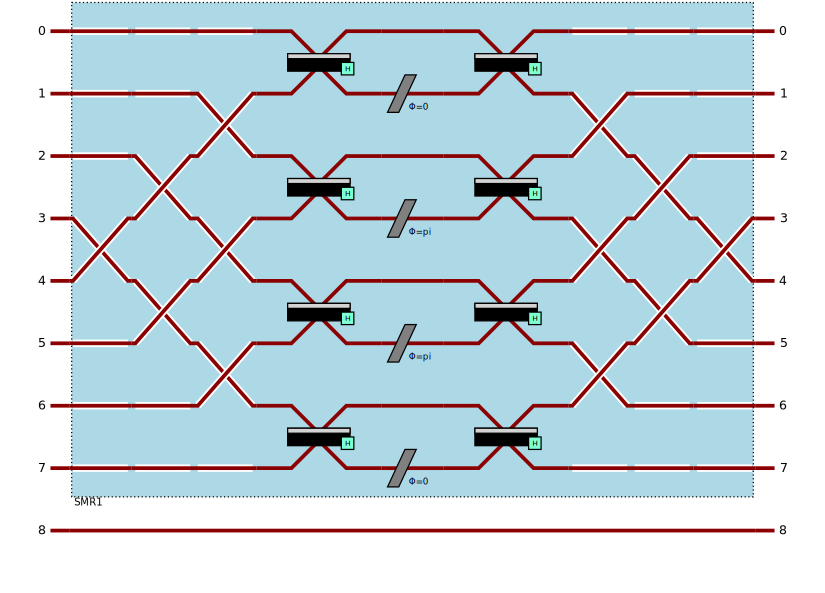

In [4]:
# Display the internal MZI structure of SMR1 with recursive=True.
# This shows the individual beam splitters (BS.H) and phase shifters (PS)
# that realise the partial swap for each trigger mode.
#
# The circuit layout is:
#   [pre-permutation layers] → [d MZI blocks, one per mode pair] → [post-permutation layers]
# For trigger mode k: internal phase phi_k = pi  → modes k (input) and k (ancilla) are swapped
# For non-trigger k:  internal phase phi_k = 0   → identity (transmission)
#
# Note: C1 and q1 must be defined (Section 2) before running this cell.
smr_display = make_SMR(4, C1, "SMR1", orientation="up")
print(f"SMR1 internal structure  |  trigger modes: C1 = {C1}")
print(f"Total modes: {smr_display.m}  (4 input qudit + 4 ancilla + 1 vacuum)")
pcvl.pdisplay(smr_display, recursive=True)

## Section 4: Ancilla Preparation and the $O_i$ Unitaries

### Ancilla state preparation

The ancilla for qudit $i$ is initialised in (Eqs. 4–5 of the manuscript):

$$|\phi'\rangle_3 = \frac{1}{\sqrt{2}}(|\xi_1\rangle_3 + |k_1\rangle_3), \qquad |\xi_1\rangle_3 = \frac{1}{\sqrt{P_1}} \sum_{i|c_i \in \mathcal{C}_1} \beta_{c_i} |i\rangle_3$$

where $P_1 = \sum_{c_i \in \mathcal{C}_1} |\beta_{c_i}|^2$ is the normalisation constant. Preparing $|\xi_i\rangle$ requires knowledge of the input amplitudes $\beta_{c_i}$ — this is the origin of the state-dependence.

The function `generate_circuit_from_sv` computes the unitary $V$ that maps the input qudit state to the ancilla initialisation state $|\phi'\rangle = \frac{1}{\sqrt{2}}(|\xi\rangle + |k\rangle)$ in the expanded ($d+1$)-mode space. It does this by constructing orthonormal bases for both the input and target states and computing $U = V_{\phi} V_{\psi}^\dagger$.

### The $O_i$ basis rotation unitaries

After the SMR, the ancilla qudits must be mapped onto a 2-dimensional subspace to construct the entangled resource state of Eq. 7 of the manuscript. The unitary $O_i$ (Eq. 18 of the manuscript) maps:
- $|k_i\rangle \to |0\rangle$ (non-trigger component → qubit $|0\rangle$)
- $|\xi_i\rangle \to |1\rangle$ (trigger component → qubit $|1\rangle$)
- remaining basis vectors → orthogonal complement

This is realised in `generate_basis_rotation_circuit` using the same orthonormal basis construction, now mapping the post-SMR ancilla state to $|0\rangle$ or $|1\rangle$ depending on orientation. Following Reck and Clements [Refs. 26, 27 of the manuscript], any such unitary is implementable as a multiport interferometer.

In [5]:
def generate_circuit_from_sv(name, initial_sv, controls, orientation="up", decomposition=False):
    """
    Build the ancilla preparation circuit for the state-dependent scheme.

    Computes the unitary that maps the (d+1)-mode vacuum-padded input state
    to the ancilla initialisation state:
        |phi> = (1/sqrt(2)) * (|xi> + |k>) ,
    where |xi> = (1/sqrt(P)) * sum_{c in controls} beta_c |c> and |k> is
    the additional independent vacuum mode (Eqs. 4-5 of the manuscript).

    Parameters
    ----------
    name        : str              -- circuit label
    initial_sv  : pcvl.StateVector -- input qudit state |psi'> or |psi''>
    controls    : list             -- trigger mode indices (C_1 or C_2)
    orientation : str              -- 'up' (vacuum appended) or 'down' (vacuum prepended)
    decomposition : bool           -- if True, display the MZI decomposition

    Returns
    -------
    pcvl.Circuit acting on n+1 modes
    """
    n = initial_sv.m   # original qudit mode count (d = 4)
    N = n + 1          # expanded mode count (d + 1 = 5)

    # Extract amplitude vector psi from the StateVector
    psi = np.zeros(n, dtype=complex)
    for state, amp in initial_sv:
        if state.n != 1:
            raise ValueError("Single-photon states required.")
        for i in range(n):
            if state[i] == 1:
                psi[i] = amp
                break

    # phi = psi restricted to trigger modes, then normalised (this is |xi>)
    phi = np.copy(psi)
    non_trigger_modes = [x for x in range(n) if x not in set(controls)]
    for mode in non_trigger_modes:
        phi[mode] = 0.0

    norm = np.linalg.norm(phi)
    if norm < 1e-10:
        raise ValueError("No trigger-mode amplitude found in the input state.")
    phi = phi / norm

    # Build (d+1)-dimensional vectors:
    # psi_expanded embeds |psi> into the larger space
    # phi_expanded = (1/sqrt(2)) * |xi> + (1/sqrt(2)) * |k>  (ancilla init state)
    psi_expanded = np.zeros(N, dtype=complex)
    phi_expanded = np.zeros(N, dtype=complex)

    if orientation == "up":
        psi_expanded[:n] = psi
        phi_expanded[:n] = phi / np.sqrt(2)
        phi_expanded[n] = 1.0 / np.sqrt(2)    # vacuum mode |k> at top
    elif orientation == "down":
        psi_expanded[1:] = psi
        phi_expanded[1:] = phi / np.sqrt(2)
        phi_expanded[0] = 1.0 / np.sqrt(2)    # vacuum mode |k> at bottom
    else:
        raise ValueError("orientation must be 'up' or 'down'")

    # Unitary: V_phi @ V_psi^dagger rotates the input state to the ancilla state
    V_psi = get_orthonormal_basis(psi_expanded)
    V_phi = get_orthonormal_basis(phi_expanded)
    U = V_phi @ V_psi.conj().T

    circuit = pcvl.Circuit(N, name)
    circuit.add(0, pcvl.Unitary(pcvl.Matrix(U)))

    if decomposition:
        U_decomp, _ = np.linalg.qr(U)
        decomposed_circuit = pcvl.Circuit.decomposition(
            pcvl.Matrix(U_decomp),
            pcvl.BS(theta=pcvl.P('theta'), phi_tr=pcvl.P('phi')),
            phase_shifter_fn=pcvl.PS
        )
        pcvl.pdisplay(decomposed_circuit)

    return circuit


def generate_basis_rotation_circuit(name, theoretical_sv, controls, U_SMR=None,
                                     orientation="up", decomposition=False):
    """
    Build the O_i basis rotation circuit (Eq. 18 of the manuscript).

    After the SMR, the ancilla qudit must be mapped to a 2-dimensional
    subspace. O_i sends |k_i> -> |0> and |xi_i> -> |1>, where:
      - orientation='down': target state is |0> (mode 0 of the ancilla)
      - orientation='up':   target state is |n-1> (last mode of the ancilla)

    Parameters
    ----------
    name          : str              -- circuit label
    theoretical_sv: pcvl.StateVector -- input qudit state |psi'> or |psi''>
    controls      : list             -- trigger mode indices
    U_SMR         : np.ndarray|None  -- optional SMR unitary to track state transformation
    orientation   : str              -- 'up' or 'down'
    decomposition : bool             -- if True, display MZI decomposition

    Returns
    -------
    pcvl.Circuit acting on n modes (ancilla dimension k_i + 1)
    """
    n = theoretical_sv.m  # qudit mode count (d = 4)

    psi = np.zeros(n, dtype=complex)
    for state, amp in theoretical_sv:
        if state.n == 1:
            for i in range(n):
                if state[i] == 1:
                    psi[i] = amp
                    break

    # phi = psi restricted to trigger modes (the |xi> component)
    phi = np.copy(psi)
    non_trigger = [x for x in range(n) if x not in set(controls)]
    for mode in non_trigger:
        phi[mode] = 0.0

    norm = np.linalg.norm(phi)
    if norm < 1e-10:
        raise ValueError("No valid trigger amplitude found in the input state.")
    phi = phi / norm

    # Optionally propagate through the SMR unitary
    state_at_O = U_SMR @ phi if U_SMR is not None else phi

    # Target state: |0> (orientation='down') or |n-1> (orientation='up')
    target_state = np.zeros(n, dtype=complex)
    if orientation == "down":
        target_state[0] = 1.0
    elif orientation == "up":
        target_state[n - 1] = 1.0
    else:
        raise ValueError("orientation must be 'up' or 'down'")

    V_psi = get_orthonormal_basis(state_at_O)
    V_target = get_orthonormal_basis(target_state)
    U = V_target @ V_psi.conj().T

    circuit = pcvl.Circuit(n, name)
    circuit.add(0, pcvl.Unitary(pcvl.Matrix(U)))

    if decomposition:
        U_decomp, _ = np.linalg.qr(U)
        decomposed_circuit = pcvl.Circuit.decomposition(
            pcvl.Matrix(U_decomp),
            pcvl.BS(theta=pcvl.P('theta'), phi_tr=pcvl.P('phi')),
            phase_shifter_fn=pcvl.PS
        )
        pcvl.pdisplay(decomposed_circuit)

    return circuit

## Section 5: Full Circuit Assembly

We now assemble the complete 18-mode optical circuit in the order specified by the manuscript (see Fig. 2):

1. **Ancilla 1 preparation** (modes 4–8): maps $q_1$ to the ancilla initialisation state $|\phi'\rangle_3$
2. **SMR1** (modes 0–8): partial swap between input qudit 1 (modes 0–3) and ancilla 3 (modes 4–8)
3. **Ancilla 2 preparation** (modes 9–13): maps $q_2$ to the ancilla initialisation state $|\phi''\rangle_4$
4. **SMR2** (modes 9–17): partial swap between ancilla 4 (modes 9–13) and input qudit 2 (modes 14–17)
5. **$O_1$** (modes 4–7): basis rotation on ancilla 3 output modes, mapping trigger/non-trigger to $|1\rangle$/$|0\rangle$
6. **$O_2$** (modes 10–13): basis rotation on ancilla 4 output modes
7. **Hadamard** (modes 9–10): applied to ancilla 4 before the BSM (see Eq. 22 of the manuscript)
8. **BSM** (modes 7–10): Bell state measurement on the two ancilla systems

The circuit diagram below shows all components. Input and output qudit modes (0–3 and 14–17) pass through unchanged.

In [6]:
# --- Step 1-4: Ancilla preparation + SMR for both qudits ---
routing_circuit = pcvl.Circuit(18)
routing_circuit.add(4, generate_circuit_from_sv("Ancilla 1 Preparation", q1, C1, orientation="up")) \
               .add(0, make_SMR(4, C1, "SMR1", orientation="up")) \
               .add(9, generate_circuit_from_sv("Ancilla 2 Preparation", q2, C2, orientation="down")) \
               .add(9, make_SMR(4, C2, "SMR2", orientation="down"))

print("Routing circuit (Ancilla Preparation + SMR1 + SMR2):")
#pcvl.pdisplay(routing_circuit, recursive=True)

Routing circuit (Ancilla Preparation + SMR1 + SMR2):


In [7]:
# --- Step 5-6: Add O1 and O2 basis rotation unitaries ---
O_circuit = routing_circuit.add(4,  generate_basis_rotation_circuit("O1", q1, C1, orientation="up",   decomposition=False)) \
                            .add(10, generate_basis_rotation_circuit("O2", q2, C2, orientation="down", decomposition=False))

print("Circuit after adding O1 and O2:")
#pcvl.pdisplay(O_circuit)

Circuit after adding O1 and O2:


Complete circuit (Ancilla Prep + SMR + O1 + O2 + Hadamard + BSM):


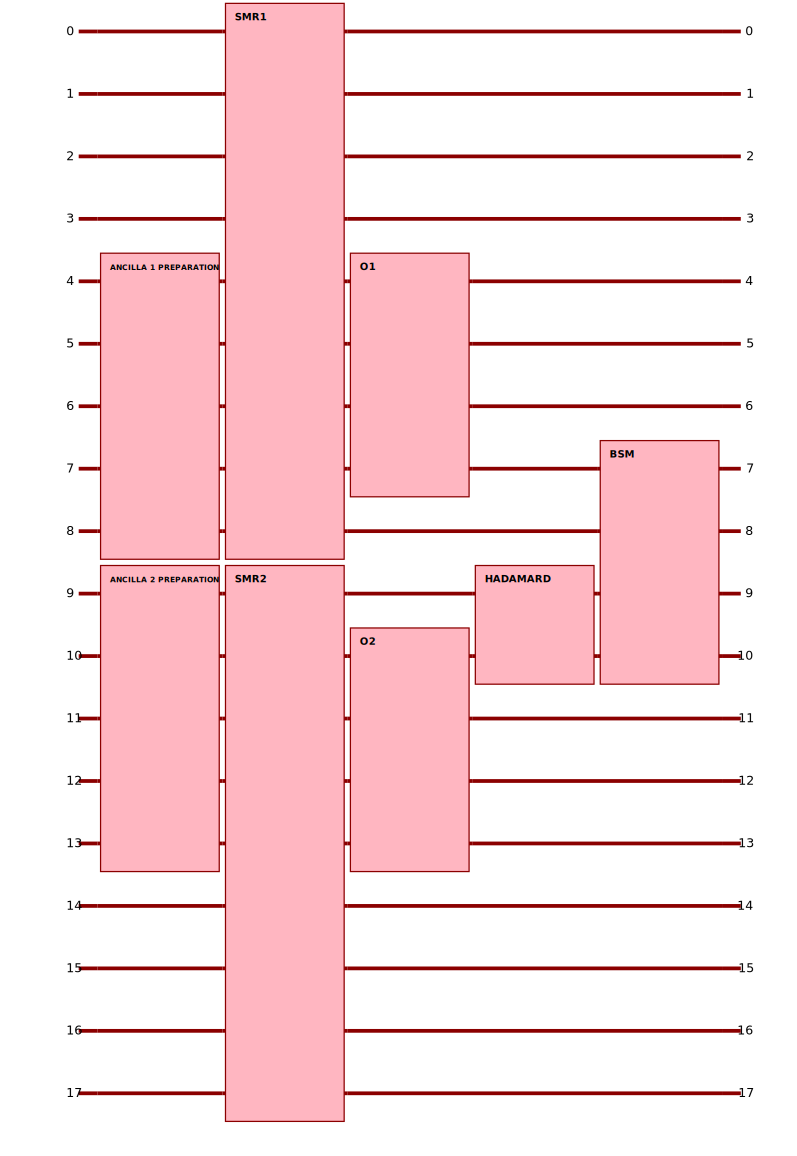

In [8]:
def Hadamard():
    """
    50:50 beam splitter acting as a Hadamard gate on a 2-mode system.
    Applied to ancilla 4 (modes 9-10) before the Bell state measurement.
    """
    circuit = pcvl.Circuit(2, "Hadamard")
    circuit.add(0, pcvl.BS.H())
    return circuit


def BSM():
    """
    Linear-optical Bell State Measurement (BSM) circuit on 4 modes.

    Realised as two 50:50 beam splitters preceded by permutations that
    route the two ancilla qubits to adjacent mode pairs. With linear
    optics, only two of the four Bell states are distinguishable,
    giving a BSM success probability of 1/2.
    """
    BSM_circ = pcvl.Circuit(4, "BSM")
    BSM_circ.add(0, pcvl.PERM([0, 2, 1, 3])) \
            .add(0, pcvl.PERM([0, 1, 3, 2])) \
            .add(0, pcvl.BS.H()) \
            .add(2, pcvl.BS.H())
    return BSM_circ


# --- Step 7-8: Add Hadamard on ancilla 4, then BSM on both ancillas ---
# Hadamard applied to modes 9-10 (ancilla 4 output in the 18-mode circuit)
# BSM applied to modes 7-10 (ancilla 3 and ancilla 4 outputs)
O_circuit.add(9, Hadamard())
BSM_circuit = O_circuit.add(7, BSM())

print("Complete circuit (Ancilla Prep + SMR + O1 + O2 + Hadamard + BSM):")
pcvl.pdisplay(BSM_circuit)

## Section 6: Simulation and Post-Selection

We evolve the full 18-mode input state $|\Psi_{\mathrm{in}}\rangle$ through the circuit using Perceval's exact `SLOSBackend` simulator.

### Post-selection conditions

After the circuit, we post-select on the **four-fold coincidence** event (Appendix of the manuscript) corresponding to exactly one photon exiting each of the four relevant SMR output ports. In terms of the global mode indices:

- **Non-trigger ancilla dump modes must be vacuum**: modes `{4, 7}` (SMR1 non-trigger outputs) and modes `{10, 13}` (SMR2 non-trigger outputs) must each have 0 photons.
- **Trigger output coincidence**: exactly one photon must appear in each of the two SMR trigger output pairs. Valid patterns is:
  - 1 photon in modes {0,1,2,3}
  - 1 photon in modes {4,5,6,7,8}

States that pass post-selection are projected back onto the 8 qudit modes (0–3 and 14–17), giving the entangled qudit state after the SMR stage.

The probability of passing post-selection is $1/4$, arising from the two SMRs each succeeding with probability $1/2$.

In [9]:
# Mode index constants — defined here for clarity and to avoid magic numbers
QUDIT1_MODES       = list(range(0, 4))   # input qudit 1: modes 0-3
ANCILLA1_DUMP      = [4, 5, 6]           # SMR1 non-trigger ancilla output modes (must be vacuum)
SMR1_TRIGGER_OUT_A = 7                   # SMR1 trigger output, pattern A
SMR1_TRIGGER_OUT_B = 8                   # SMR1 trigger output, pattern B
SMR2_TRIGGER_OUT_A = 9                   # SMR2 trigger output, pattern A
SMR2_TRIGGER_OUT_B = 10                  # SMR2 trigger output, pattern B
ANCILLA2_DUMP      = [11, 12, 13]        # SMR2 non-trigger ancilla output modes (must be vacuum)
QUDIT2_MODES       = list(range(14, 18)) # input qudit 2: modes 14-17

# Run the full simulation
simulator = pcvl.Simulator(pcvl.SLOSBackend())
simulator.set_circuit(BSM_circuit)
final_state = simulator.evolve(total_state_vector)

print(f"Simulation complete. Total output terms before post-selection: {len(final_state)}")

Simulation complete. Total output terms before post-selection: 344


In [10]:
def post_select_and_extract(output_state, threshold=1e-6):
    """
    Apply the four-fold coincidence post-selection condition to the
    output state of the full BSM circuit, then project onto the
    8-mode qudit subspace (modes 0-3 and 14-17).

    Post-selection conditions (see Section 6 above):
      1. Non-trigger ancilla dump modes must be vacuum:
         modes {4, 5, 6} = 0 and modes {11, 12, 13} = 0
      2. Trigger output coincidence (one of two valid patterns):
         Pattern A: mode 7 = 1, mode 9  = 1, mode 8  = 0, mode 10 = 0
         Pattern B: mode 8 = 1, mode 10 = 1, mode 7  = 0, mode 9  = 0

    Amplitudes below `threshold` are treated as numerical noise and dropped.

    Parameters
    ----------
    output_state : pcvl.StateVector -- full 18-mode output after circuit evolution
    threshold    : float            -- minimum amplitude magnitude to retain

    Returns
    -------
    pcvl.StateVector -- normalised, projected 8-mode post-selected state
    """
    filtered_state = pcvl.StateVector()
    valid_found = False

    for state, amplitude in output_state:
        # Drop negligible amplitudes (numerical noise)
        if abs(amplitude) < threshold:
            continue

        # Condition 1: non-trigger dump modes must all be vacuum
        dump_photons = sum(state[i] for i in ANCILLA1_DUMP + ANCILLA2_DUMP)
        if dump_photons != 0:
            continue

        # Condition 2: exactly one photon in each trigger output pair
        pattern_A = (state[SMR1_TRIGGER_OUT_A] == 1 and state[SMR2_TRIGGER_OUT_A] == 1 and
                     state[SMR1_TRIGGER_OUT_B] == 0 and state[SMR2_TRIGGER_OUT_B] == 0)
        pattern_B = (state[SMR1_TRIGGER_OUT_B] == 1 and state[SMR2_TRIGGER_OUT_B] == 1 and
                     state[SMR1_TRIGGER_OUT_A] == 0 and state[SMR2_TRIGGER_OUT_A] == 0)

        if not (pattern_A or pattern_B):
            continue

        # Project: extract only the qudit modes (0-3 and 14-17)
        qudit_fock = tuple(state[i] for i in QUDIT1_MODES) + tuple(state[i] for i in QUDIT2_MODES)
        filtered_state += amplitude * pcvl.BasicState(qudit_fock)
        valid_found = True

    if not valid_found:
        print("WARNING: No states passed the post-selection criteria.")
        return filtered_state

    filtered_state.normalize()
    return filtered_state


post_selected_state = post_select_and_extract(final_state)

print("Post-selected output state (8 qudit modes, normalised):")
print(post_selected_state)

Post-selected output state (8 qudit modes, normalised):
0.258*|0,0,0,1,0,0,1,0>+0.097*|1,0,0,0,1,0,0,0>+0.183*|0,0,1,0,0,0,1,0>+0.075*|1,0,0,0,0,0,1,0>+0.566*|0,0,0,1,0,0,0,1>-0.163*|0,1,0,0,0,0,0,1>+0.224*|0,0,1,0,0,1,0,0>+0.075*|0,1,0,0,0,0,1,0>-0.097*|0,1,0,0,1,0,0,0>+0.091*|1,0,0,0,0,1,0,0>+0.337*|0,0,0,1,1,0,0,0>+0.316*|0,0,0,1,0,1,0,0>-0.238*|0,0,1,0,1,0,0,0>-0.4*|0,0,1,0,0,0,0,1>+0.163*|1,0,0,0,0,0,0,1>+0.091*|0,1,0,0,0,1,0,0>


## Section 7: Verification Against Theoretical Prediction

We verify the simulation result by computing $U_{\mathrm{MCZ}}|\psi\rangle_{12}$ analytically and comparing it to the post-selected simulation output.

### Theoretical prediction

The $U_{\mathrm{MCZ}}$ gate (Eq. 2 of the manuscript) acts on the joint state $|\psi\rangle_{12} = |\psi'\rangle_1 \otimes |\psi''\rangle_2$ as follows:

$$U_{\mathrm{MCZ}} \left(\sum_{m,n} \beta_m \gamma_n |m\rangle_1|n\rangle_2\right) = \sum_{m \notin \mathcal{C}_1\text{ or } n \notin \mathcal{C}_2} \beta_m \gamma_n |m\rangle_1|n\rangle_2 - \sum_{m \in \mathcal{C}_1,\, n \in \mathcal{C}_2} \beta_m \gamma_n |m\rangle_1|n\rangle_2$$

That is, all terms with $(m, n) \in \mathcal{C}_1 \times \mathcal{C}_2$ receive a phase flip of $-1$; all other terms are unchanged.

### Comparison metric

We compute the **fidelity** between the theoretical and simulated states:

$$F = |\langle \psi_{\mathrm{theory}} | \psi_{\mathrm{sim}} \rangle|^2$$

A fidelity of 1.0 (within numerical precision) confirms that the Perceval simulation correctly implements $U_{\mathrm{MCZ}}$ up to the BSM outcome-dependent local unitary corrections.

In [11]:
def apply_UMCZ(q1_sv, q2_sv, C1, C2):
    """
    Analytically compute U_MCZ |psi>_{12} for single-photon qudits.

    Applies a phase flip of -1 to every term |m>|n> where m in C1 and n in C2;
    all other terms are left unchanged.

    Parameters
    ----------
    q1_sv : pcvl.StateVector -- state of qudit 1
    q2_sv : pcvl.StateVector -- state of qudit 2
    C1    : list             -- trigger mode indices for qudit 1
    C2    : list             -- trigger mode indices for qudit 2

    Returns
    -------
    pcvl.StateVector -- the 8-mode joint state after U_MCZ
    """
    C1_set = set(C1)
    C2_set = set(C2)
    result = pcvl.StateVector()

    for s1, a1 in q1_sv:
        for s2, a2 in q2_sv:
            # Identify which mode is occupied in each single-photon state
            m = next(i for i in range(s1.m) if s1[i] == 1)
            n = next(i for i in range(s2.m) if s2[i] == 1)

            # Phase flip if (m, n) in C1 x C2
            phase = -1 if (m in C1_set and n in C2_set) else +1

            # Build 8-mode Fock state [qudit1 modes | qudit2 modes]
            fock = [0] * 8
            fock[m] = 1       # qudit 1 occupies mode m (global positions 0-3)
            fock[4 + n] = 1   # qudit 2 occupies mode n (global positions 4-7)
            result += (phase * a1 * a2) * pcvl.BasicState(fock)

    result.normalize()
    return result


def compute_fidelity(sv_sim, sv_theory):
    """
    Compute the fidelity F = |<theory|sim>|^2 between two normalised
    StateVectors over the same mode space.
    """
    # Build amplitude dictionaries keyed by basis state tuple
    def to_dict(sv):
        d = {}
        for state, amp in sv:
            key = tuple(state)
            d[key] = d.get(key, 0) + amp
        return d

    d_sim    = to_dict(sv_sim)
    d_theory = to_dict(sv_theory)

    # Inner product <theory|sim>
    overlap = sum(np.conj(d_theory.get(k, 0)) * d_sim.get(k, 0)
                  for k in set(d_sim) | set(d_theory))
    return abs(overlap) ** 2


# Compute theoretical prediction
theoretical_state = apply_UMCZ(q1, q2, C1, C2)

# Compute fidelity
fidelity = compute_fidelity(post_selected_state, theoretical_state)

print("=" * 60)
print("VERIFICATION RESULTS")
print("=" * 60)
print(f"Trigger sets: C1 = {C1},  C2 = {C2}")
print()
print("Theoretical prediction  U_MCZ |psi>_{12}:")
print(theoretical_state)
print()
print("Simulation output (post-selected):")
print(post_selected_state)
print()
print(f"Fidelity F = |<theory|sim>|^2 = {fidelity:.6f}")
if fidelity > 0.999:
    print("PASS: Simulation matches theoretical prediction within numerical precision.")
else:
    print(f"FAIL: Fidelity below threshold (got {fidelity:.4f}, expected ~1.0).")
print("=" * 60)

VERIFICATION RESULTS
Trigger sets: C1 = [1, 2],  C2 = [0, 3]

Theoretical prediction  U_MCZ |psi>_{12}:
0.258*|0,0,0,1,0,0,1,0>+0.097*|1,0,0,0,1,0,0,0>+0.075*|1,0,0,0,0,0,1,0>-0.097*|0,1,0,0,1,0,0,0>+0.091*|1,0,0,0,0,1,0,0>-0.4*|0,0,1,0,0,0,0,1>+0.163*|1,0,0,0,0,0,0,1>-0.238*|0,0,1,0,1,0,0,0>+0.183*|0,0,1,0,0,0,1,0>+0.224*|0,0,1,0,0,1,0,0>+0.075*|0,1,0,0,0,0,1,0>+0.091*|0,1,0,0,0,1,0,0>-0.163*|0,1,0,0,0,0,0,1>+0.337*|0,0,0,1,1,0,0,0>+0.316*|0,0,0,1,0,1,0,0>+0.566*|0,0,0,1,0,0,0,1>

Simulation output (post-selected):
0.258*|0,0,0,1,0,0,1,0>+0.097*|1,0,0,0,1,0,0,0>+0.183*|0,0,1,0,0,0,1,0>+0.075*|1,0,0,0,0,0,1,0>+0.566*|0,0,0,1,0,0,0,1>-0.163*|0,1,0,0,0,0,0,1>+0.224*|0,0,1,0,0,1,0,0>+0.075*|0,1,0,0,0,0,1,0>-0.097*|0,1,0,0,1,0,0,0>+0.091*|1,0,0,0,0,1,0,0>+0.337*|0,0,0,1,1,0,0,0>+0.316*|0,0,0,1,0,1,0,0>-0.238*|0,0,1,0,1,0,0,0>-0.4*|0,0,1,0,0,0,0,1>+0.163*|1,0,0,0,0,0,0,1>+0.091*|0,1,0,0,0,1,0,0>

Fidelity F = |<theory|sim>|^2 = 1.000000
PASS: Simulation matches theoretical prediction within

## Summary

This notebook has demonstrated a complete Perceval simulation of the state-dependent multi-level CZ gate for $d = 4$ qudits. The trigger sets `C1` and `C2` are set in Section 2 and can be changed freely to any non-empty subsets of `{0, 1, 2, 3}` — the gate $U_{\mathrm{MCZ}}$ is correctly realised for any such choice with success probability $1/8$.

| Stage | Description | Key result |
|---|---|---|
| Ancilla preparation | Maps input qudit to $|\phi'\rangle = \frac{1}{\sqrt{2}}(|\xi\rangle + |k\rangle)$ | Requires *a priori* knowledge of $|\psi'\rangle$, $|\psi''\rangle$ |
| SMR1 + SMR2 | Partial swap on trigger modes; heralded by single-photon coincidence | Each succeeds with probability $1/2$; combined probability $1/4$ |
| $O_1$, $O_2$ | Basis rotation to 2D subspace | Maps trigger/non-trigger indicator to $|1\rangle$/$|0\rangle$ |
| Hadamard + BSM | Bell state measurement on ancillas | Distinguishes 2 of 4 Bell states; contributes factor $1/2$ |
| **Overall** | Post-selected output matches $U_{\mathrm{MCZ}}|\psi\rangle_{12}$ | **Success probability: $1/8$** |

The fidelity computed in Section 7 confirms that the photonic circuit correctly implements $U_{\mathrm{MCZ}}$ as defined in Eq. 2 of the manuscript, up to known local unitary corrections $U_1$, $U_2$ that depend on the BSM measurement outcome (Eq. 26 of the manuscript) and are applied classically via feedforward.

For further details on the construction, the complete analytical derivation, and the state-independent scheme, see the full manuscript at arXiv:2602.08394v1.